# Test: ParticleSpringForceDiffusionField generator

Visualize 3D particles with spring forces + chemotaxis from a diffusion-decay field with cell sources.

PDE: dc/dt = D * laplacian(c) - lambda * c + alpha * sum_i delta(x - x_i)

Three panels per frame:
1. 3D scatter of particle positions
2. Top-down (xy) projection of particles colored by local field value
3. Top-down field slice (z=0.5) with particles overlaid

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import trange
from IPython.display import Video, display
import matplotlib.animation as animation

from cell_gnn.cell_state import CellState
from cell_gnn.utils import edges_radius_blockwise, choose_boundary_values
from cell_gnn.generators.particle_spring_force_diffusion_field import (
    ParticleSpringForceDiffusionField,
)
from cell_gnn.integrators import rk4_step

## Parameters

In [16]:
device = 'cpu'

# simulation
n_cells = 1000
dimension = 3
n_frames = 4000
delta_t = 0.002
max_radius = 0.15
min_radius = 0.0
noise_level = 0.01

# spring force params: [k_rep, r0, kadh, r_on, delta, mu_f]
cell_params = torch.tensor([50.0, 0.1, 50.0, 0.14, 0.001, 0.033], device=device)

# diffusion field params
grid_resolution = 64

field_params = {
    # PDE coefficients
    'diffusion_coeff': 0.1,     # D
    'lambda_decay': 0.1,         # lambda (low so source can accumulate)
    'grid_resolution': grid_resolution,
    'source_strength': 5.0,       # alpha — high enough that cell secretion is visible
    # initial condition: no blobs — field built purely from cell sources
    'center_0': torch.tensor([
        [0.50, 0.50, 0.50],
    ], device=device),
    'amplitude': 0.0,             # start with zero field
    'sigma': 0.05,
    # chemotaxis coupling
    'mu_chem': 0.02,
    'delta_t': delta_t,
    'periodic': True,
}

# boundary conditions
bc_pos, bc_dpos = choose_boundary_values('periodic')

# Steady-state estimate: alpha * n_cells * dt / (lambda * res^3)
ss_est = field_params['source_strength'] * n_cells * delta_t / (field_params['lambda_decay'] * grid_resolution**3)
print(f"D = {field_params['diffusion_coeff']}, lambda = {field_params['lambda_decay']}")
print(f"source_strength = {field_params['source_strength']}")
print(f"grid_resolution = {grid_resolution}^3 = {grid_resolution**3} points")
print(f"mu_chem = {field_params['mu_chem']}")
print(f"Estimated steady-state per-cell contribution: {ss_est:.4f}")

D = 0.1, lambda = 0.1
source_strength = 5.0
grid_resolution = 64^3 = 262144 points
mu_chem = 0.02
Estimated steady-state per-cell contribution: 0.0004


## Initialize cells & model

In [17]:
torch.manual_seed(42)

# random initial positions in [0,1]^3
pos = torch.rand(n_cells, dimension, device=device)
vel = torch.zeros(n_cells, dimension, device=device)

x = CellState(
    index=torch.arange(n_cells, device=device),
    pos=pos,
    vel=vel,
    cell_type=torch.zeros(n_cells, dtype=torch.long, device=device),
    field=torch.ones(n_cells, 1, device=device),
)

model = ParticleSpringForceDiffusionField(
    aggr_type='add',
    p=cell_params,
    bc_dpos=bc_dpos,
    dimension=dimension,
    noise_model_level=noise_level,
    field_params=field_params,
)

print(f'Cells: {n_cells}, Frames: {n_frames}, dt: {delta_t}')

Cells: 1000, Frames: 4000, dt: 0.002


## Run simulation

In [ ]:
# store snapshots for video
save_every = 10
pos_history = []
field_history = []       # per-particle field value at each snapshot
field_grid_history = []  # full z=0.5 grid slice at each snapshot
time_history = []

for it in trange(n_frames, ncols=100, desc='simulating'):
    # RK4 step (this advances the PDE internally)
    def _deriv_fn(s, _it=it):
        ei = edges_radius_blockwise(s.pos, bc_dpos, min_radius, max_radius, block=2048)
        return model(s, ei, k=_it)

    x, _ = rk4_step(x, _deriv_fn, delta_t, 'first_derivative', bc_pos)

    # save snapshot
    if it % save_every == 0:
        t = it * delta_t
        pos_history.append(x.pos.clone().detach().numpy())
        field_history.append(x.field.clone().detach().squeeze().numpy())
        time_history.append(t)
        # grab z=0.5 slice from the internal grid
        grid = model._field_grid.detach().cpu().numpy()
        z_mid = grid_resolution // 2
        field_grid_history.append(grid[z_mid, :, :].copy())

print(f'Saved {len(pos_history)} snapshots')

simulating:  83%|███████████████████████████████████████        | 3322/4000 [01:45<00:22, 30.60it/s]

In [ ]:
pos_history = np.array(pos_history)
field_history = np.array(field_history)
field_grid_history = np.array(field_grid_history)
time_history = np.array(time_history)

n_snapshots = len(time_history)
print(f'{n_snapshots} frames, time range [{time_history[0]:.3f}, {time_history[-1]:.3f}]')
print(f'Field grid range over all snapshots: [{field_grid_history.min():.4f}, {field_grid_history.max():.4f}]')

800 frames, time range [0.000, 15.980]
Field grid range over all snapshots: [-0.0017, 1.1569]


## Preview: field evolution (z=0.5 slices)

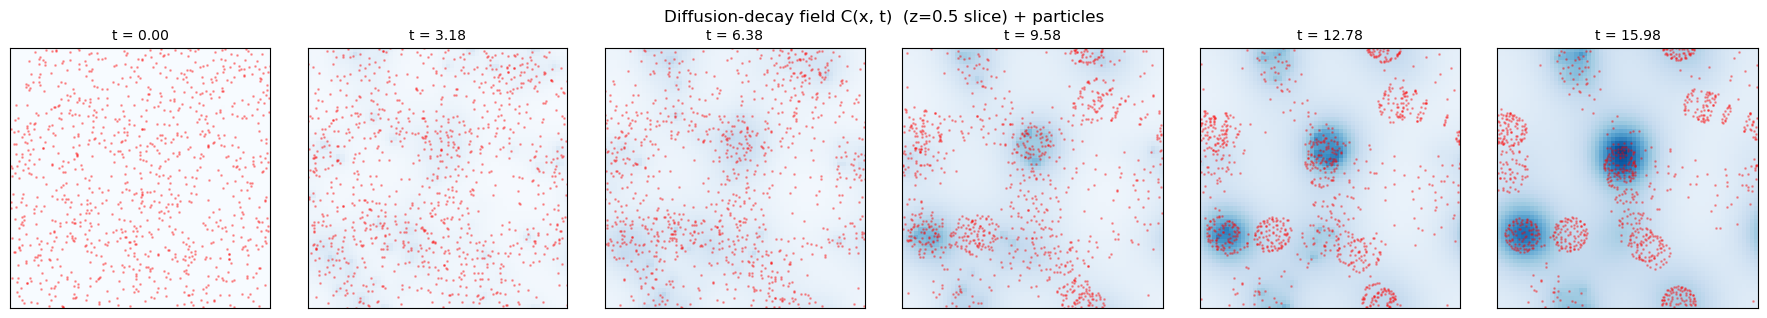

In [ ]:
# Show field slices at 6 evenly spaced snapshots
preview_indices = np.linspace(0, n_snapshots - 1, 6, dtype=int)
vmax_preview = field_grid_history.max()

fig, axes = plt.subplots(1, len(preview_indices), figsize=(3 * len(preview_indices), 3.2))
for i, idx in enumerate(preview_indices):
    ax = axes[i]
    img = field_grid_history[idx]
    im = ax.imshow(img, extent=[0, 1, 0, 1], origin='lower',
                   cmap='Blues', vmin=0, vmax=vmax_preview)
    # overlay particle xy positions
    pos = pos_history[idx]
    ax.scatter(pos[:, 0], pos[:, 1], s=1, c='red', alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_title(f't = {time_history[idx]:.2f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Diffusion-decay field C(x, t)  (z=0.5 slice) + particles', fontsize=12)
plt.tight_layout()
plt.show()

## Generate video

In [ ]:
out_dir = Path('../tmp_training/diffusion_field_test')
out_dir.mkdir(parents=True, exist_ok=True)

vmax_field = field_grid_history.max()
vmax_particle = field_history.max()

fig = plt.figure(figsize=(18, 6))

# panel 1: 3D scatter
ax1 = fig.add_subplot(131, projection='3d')
# panel 2: top-down particles
ax2 = fig.add_subplot(132)
# panel 3: top-down field + particles
ax3 = fig.add_subplot(133)


def update(frame_idx):
    pos = pos_history[frame_idx]
    t = time_history[frame_idx]
    fvals = field_history[frame_idx]
    field_img = field_grid_history[frame_idx]

    # --- Panel 1: 3D ---
    ax1.cla()
    ax1.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=3, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_particle, alpha=0.7)
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_zlim(0, 1)
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
    ax1.set_title(f'3D  t={t:.3f}')

    # --- Panel 2: top-down xy ---
    ax2.cla()
    ax2.scatter(pos[:, 0], pos[:, 1], s=3, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_particle, alpha=0.7)
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect('equal')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_title('Top-down particles')

    # --- Panel 3: field slice + particles ---
    ax3.cla()
    ax3.imshow(field_img, extent=[0, 1, 0, 1], origin='lower',
               cmap='Blues', vmin=0, vmax=vmax_field, alpha=0.8)
    ax3.scatter(pos[:, 0], pos[:, 1], s=3, c='red', alpha=0.5)
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal')
    ax3.set_xlabel('x'); ax3.set_ylabel('y')
    ax3.set_title('Field (z=0.5) + particles')

    fig.suptitle(f'Frame {frame_idx}/{n_snapshots}  t={t:.3f}', fontsize=14)
    fig.tight_layout()


print('Rendering video...')
ani = animation.FuncAnimation(fig, update, frames=n_snapshots, interval=50)
video_path = str(out_dir / 'diffusion_field_test.mp4')
ani.save(video_path, writer='ffmpeg', fps=30, dpi=100)
plt.close(fig)
print(f'Saved: {video_path}')

Rendering video...
Saved: ../tmp_training/diffusion_field_test/diffusion_field_test.mp4


In [ ]:
display(Video(video_path, embed=True, width=900))

## Static snapshots (first, middle, last)

In [ ]:
snap_indices = [0, n_snapshots // 2, n_snapshots - 1]

fig, axes = plt.subplots(len(snap_indices), 3, figsize=(18, 6 * len(snap_indices)))

for row, idx in enumerate(snap_indices):
    pos = pos_history[idx]
    t = time_history[idx]
    fvals = field_history[idx]
    field_img = field_grid_history[idx]

    # 3D
    ax = fig.add_subplot(len(snap_indices), 3, row * 3 + 1, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=5, c=fvals, cmap='YlOrRd',
              vmin=0, vmax=vmax_particle, alpha=0.7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
    ax.set_title(f'3D  t={t:.3f}')

    # top-down particles
    ax2 = axes[row, 1]
    ax2.scatter(pos[:, 0], pos[:, 1], s=5, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_particle, alpha=0.7)
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect('equal')
    ax2.set_title(f'Top-down  t={t:.3f}')

    # field + particles
    ax3 = axes[row, 2]
    ax3.imshow(field_img, extent=[0, 1, 0, 1], origin='lower',
              cmap='Blues', vmin=0, vmax=vmax_field, alpha=0.8)
    ax3.scatter(pos[:, 0], pos[:, 1], s=5, c='red', alpha=0.5)
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal')
    ax3.set_title(f'Field + particles  t={t:.3f}')

    # hide the axes[row, 0] since we replaced it with 3D projection
    axes[row, 0].set_visible(False)

fig.tight_layout()
fig.savefig(str(out_dir / 'snapshots.png'), dpi=150)
plt.show()
print(f'Saved snapshots to {out_dir / "snapshots.png"}')